# WaDI Experiments

## Load Data

In [1]:
# Load wadi data
from bdm.Experiments.data_loader import wadi_data

train_df, test_df, signal_variables, control_variables, dict_continuous_variables, dict_discrete_variables = wadi_data()
print(train_df.values.shape, test_df.values.shape)

(241921, 127) (15701, 129)


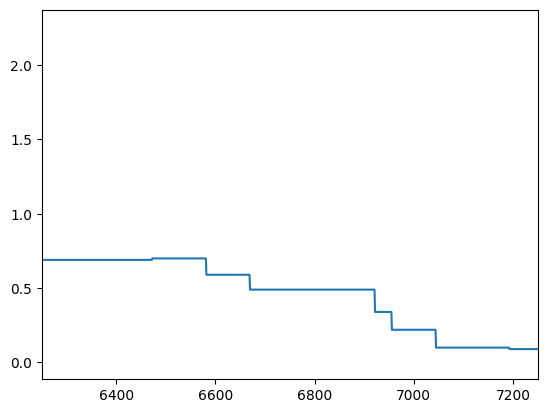

In [2]:
# Prepare data for RS
import numpy as np
import matplotlib.pyplot as plt

x = train_df.values

x -= np.mean(x, axis=0, keepdims=True)
x[:, np.std(x, axis=0) > 0] /= np.std(x, axis=0, keepdims=True)[:, np.std(x, axis=0) > 0]

x = np.nan_to_num(x, nan=0)

# TOTAL_CONS_REQUIRED_FLOW changes at 711
x_esn_fit = x[:1200]
# x_rhy_fit = x[400:900]
x_rhy_fit = x[6600-100-200-100:6600+200]

plt.plot(train_df["TOTAL_CONS_REQUIRED_FLOW"])
plt.xlim([6250, 7250])
plt.show()

# Swat ones
# x_esn_fit = x[:1200]
# x_rhy_fit = x[280:580]

## Find hyperparams

In [3]:
# Find hp

from rhythmic_sharing import RhythmicNetwork

from tqdm import tqdm
import numpy as np

best_mse = np.inf

for iw in np.linspace(0.1, 0.2, 10): # np.linspace(0.1, 0.5, 10):
    network = RhythmicNetwork(
        # Tune Rhythmic Sharing
        dt=10,
        input_dims=x.shape[1],
        spectral_radius=0.5,
        input_weight=iw,
        average_degree_nodes=8,
        num_nodes=768, #512,
        leakage=0,
        # Rhythmic params
        link_strength_change_ratio=0
    )
    
    for sr in tqdm(np.linspace(0.1, 0.2, 10)): # tqdm(np.linspace(0.1, 0.5, 10)):
        for l in np.linspace(0.4, 0.5, 10): # np.linspace(0.25, 0.5, 10):
            network.change_spectral_rad_and_leakage(sr, l)

            network.train(x_esn_fit.T[:, :-200])
            pred = network.predict(x_esn_fit.T[:, -300:], warmup_time=100)
            mse = np.mean(np.square((pred[:, 1:] - x_esn_fit.T[:, -200:]))) # /np.std(pred[:, 1:], axis=1, keepdims=True)))
            if mse > 100_000_000:
                network.lsqrs = not network.lsqrs
        
            if mse < best_mse:
                print("New best %.10f" % mse, (sr, iw, l))
                best_esn_param = (sr, iw, l)
                best_mse = mse

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

New best 740344811263940.6250000000 (np.float64(0.1), np.float64(0.1), np.float64(0.4))


  0%|                                                                                           | 0/10 [01:16<?, ?it/s]


KeyboardInterrupt: 

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

New best 0.0006920649 (np.float64(0.25), np.float64(-0.1), np.float64(0.3), np.float64(0.01))


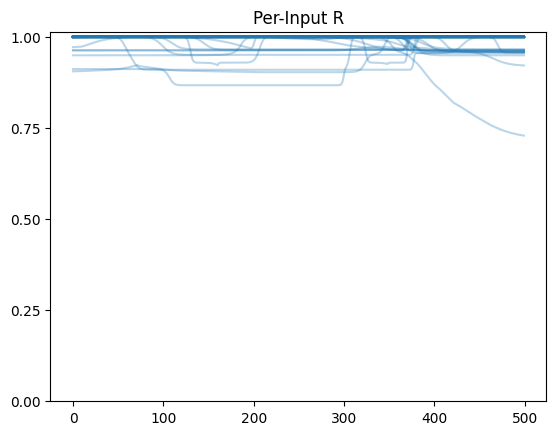

New best 0.0009938603 (np.float64(0.25), np.float64(-0.1), np.float64(0.5333333333333333), np.float64(0.01))


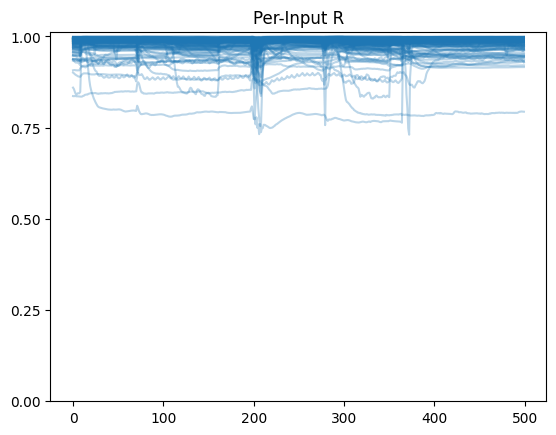

New best 0.0188668660 (np.float64(0.25), np.float64(-0.1), np.float64(0.6111111111111112), np.float64(0.01))


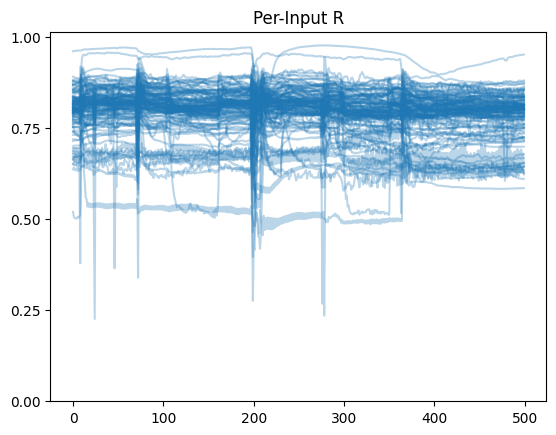

New best 0.0192550730 (np.float64(0.3333333333333333), np.float64(-0.1), np.float64(0.6111111111111112), np.float64(0.01))


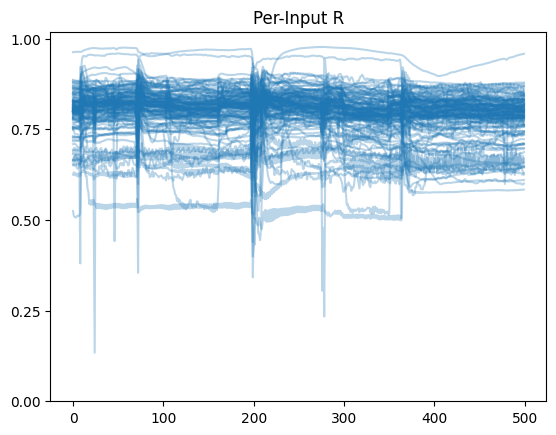

New best 0.0192794572 (np.float64(0.41666666666666663), np.float64(-0.1), np.float64(0.6111111111111112), np.float64(0.01))


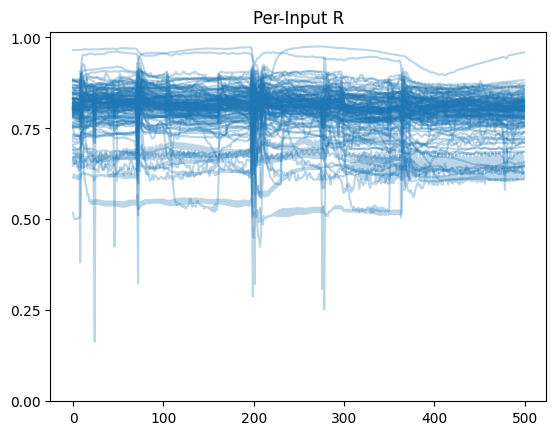

Switching to lsqr
New best 0.0196392109 (np.float64(0.75), np.float64(-0.1), np.float64(0.6111111111111112), np.float64(0.01))


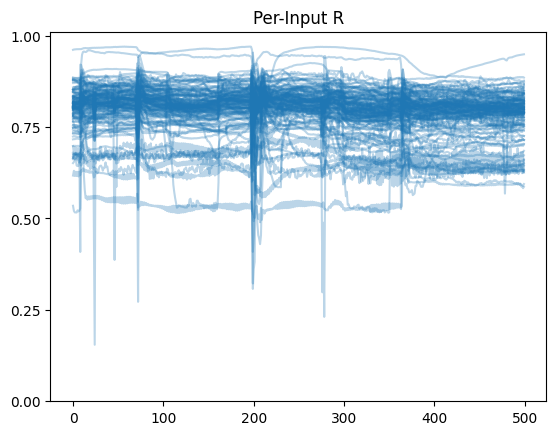

New best 0.0207120913 (np.float64(1.0), np.float64(-0.1), np.float64(0.6111111111111112), np.float64(0.01))


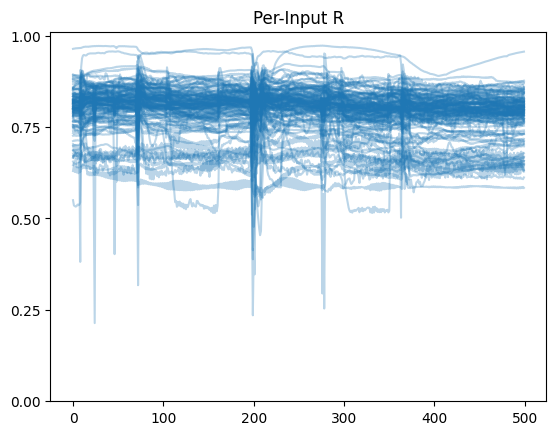

 20%|███████████████▍                                                             | 2/10 [1:32:37<6:11:12, 2784.05s/it]

New best 0.0221662896 (np.float64(0.25), np.float64(-0.12222222222222223), np.float64(0.3), np.float64(0.01))


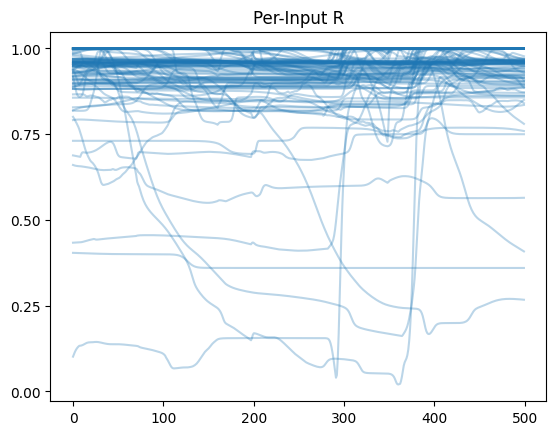

New best 0.0227094136 (np.float64(0.3333333333333333), np.float64(-0.12222222222222223), np.float64(0.3), np.float64(0.01))


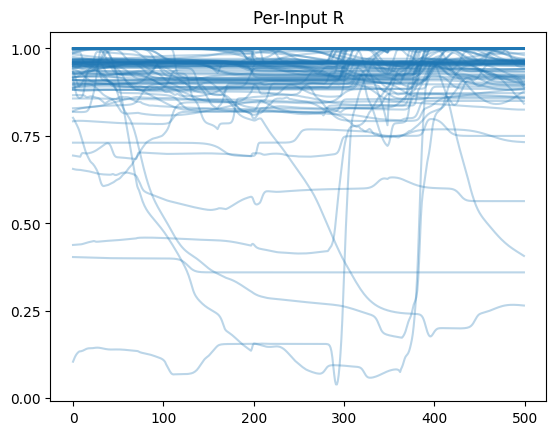

New best 0.0227881895 (np.float64(0.5), np.float64(-0.12222222222222223), np.float64(0.3), np.float64(0.01))


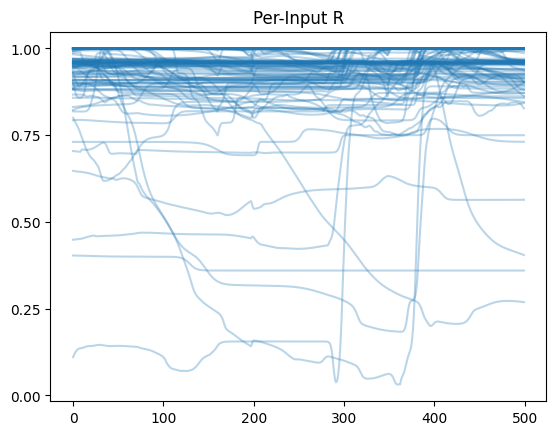

New best 0.0228982947 (np.float64(0.5833333333333333), np.float64(-0.12222222222222223), np.float64(0.3), np.float64(0.01))


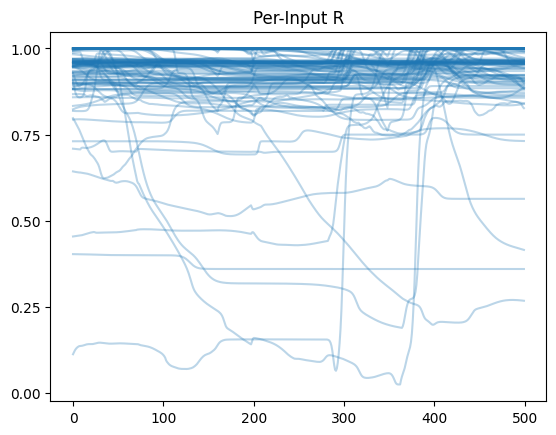

 30%|███████████████████████                                                      | 3/10 [2:14:46<5:11:13, 2667.64s/it]

New best 0.0543375382 (np.float64(0.25), np.float64(-0.13333333333333336), np.float64(0.3), np.float64(0.01))


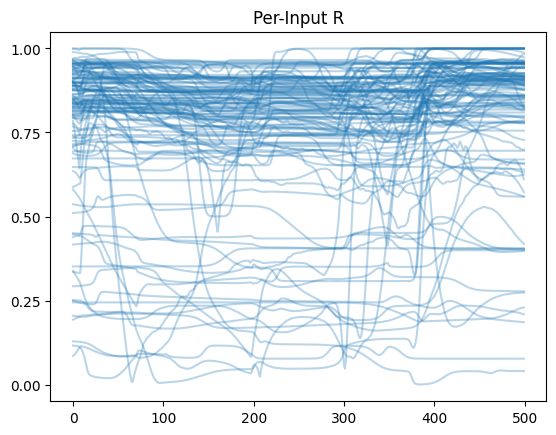

New best 0.0556966232 (np.float64(0.3333333333333333), np.float64(-0.13333333333333336), np.float64(0.3), np.float64(0.01))


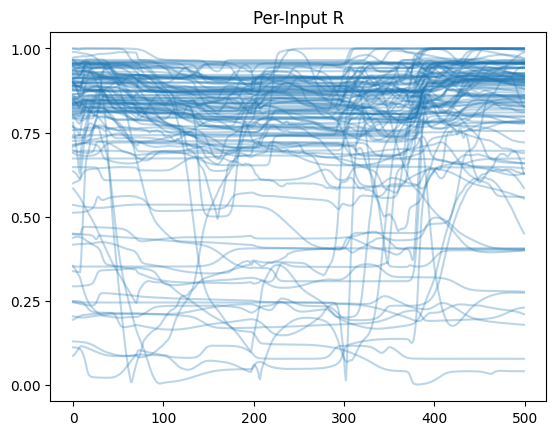

New best 0.0559982146 (np.float64(0.6666666666666666), np.float64(-0.13333333333333336), np.float64(0.3), np.float64(0.01))


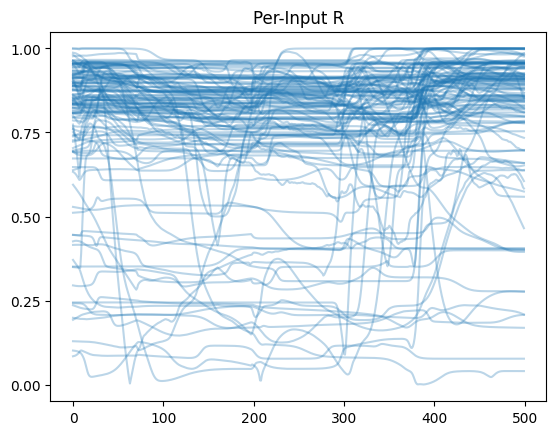

New best 0.0565207105 (np.float64(0.9166666666666666), np.float64(-0.13333333333333336), np.float64(0.3), np.float64(0.01))
New best 0.0566008884 (np.float64(1.0), np.float64(-0.13333333333333336), np.float64(0.3), np.float64(0.01))


 60%|██████████████████████████████████████████████▏                              | 6/10 [3:58:23<2:24:23, 2165.90s/it]

New best 0.0567596922 (np.float64(0.6666666666666666), np.float64(-0.16666666666666669), np.float64(0.37777777777777777), np.float64(0.01))


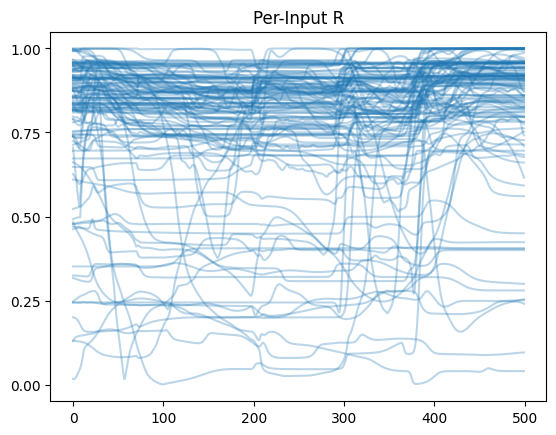

New best 0.0573165702 (np.float64(0.75), np.float64(-0.16666666666666669), np.float64(0.37777777777777777), np.float64(0.01))


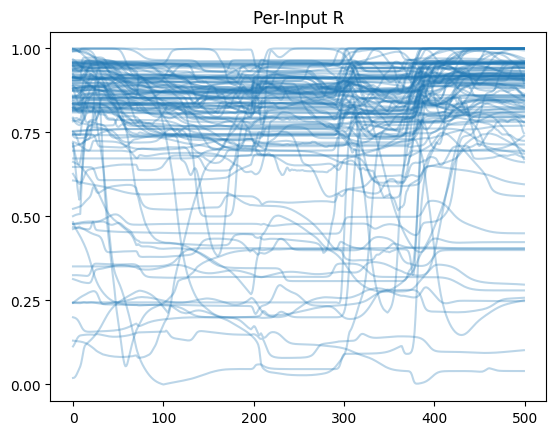

New best 0.0577847270 (np.float64(0.8333333333333333), np.float64(-0.16666666666666669), np.float64(0.37777777777777777), np.float64(0.01))


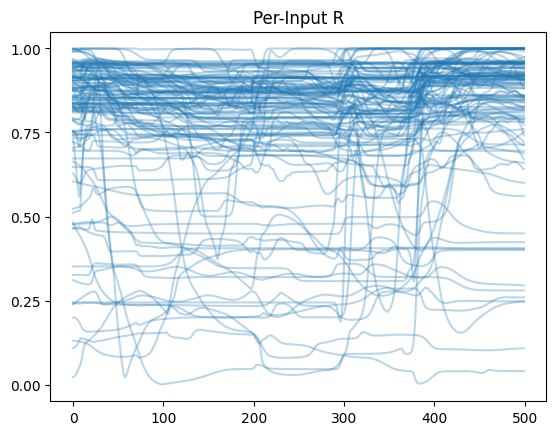

New best 0.0587505684 (np.float64(1.0), np.float64(-0.16666666666666669), np.float64(0.37777777777777777), np.float64(0.01))


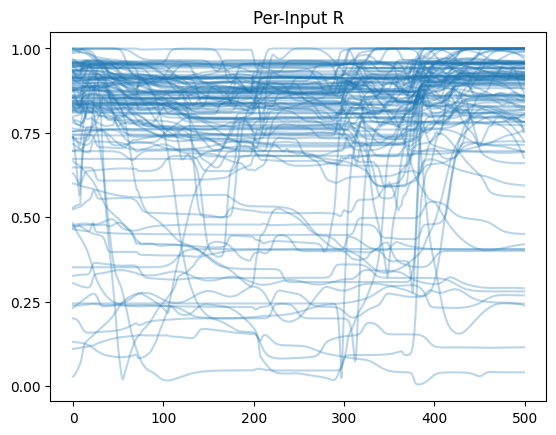

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

Switching to lsqr


 90%|███████████████████████████████████████████████████████████████████████        | 9/10 [4:47:07<35:56, 2156.70s/it]

New best 0.0590406156 (np.float64(0.25), np.float64(-0.2), np.float64(0.45555555555555555), np.float64(0.05333333333333334))


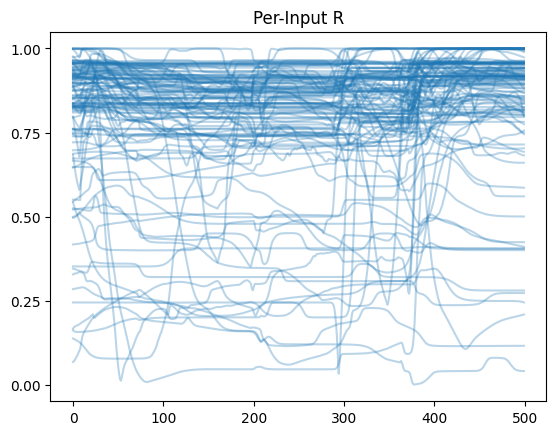

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

Switching to lsqr


 60%|██████████████████████████████████████████████▏                              | 6/10 [3:57:00<2:22:06, 2131.75s/it]

In [ ]:
import matplotlib.pyplot as plt

best_difference = 0

for o in np.linspace(0.01, 0.4, 10): # np.linspace(0.25, 0.35, 10):
    network = RhythmicNetwork(
        # Tune Rhythmic Sharing
        dt=10,
        input_dims=x.shape[1],
        spectral_radius=best_esn_param[0],
        input_weight=best_esn_param[1],
        average_degree_nodes=8,
        num_nodes=768,
        leakage=best_esn_param[2],
        # Rhythmic params
        link_strength_change_ratio=0,
        omega0=o,
        epsilon1=0,
        epsilon2=0,
    )
    
    for e1 in tqdm(np.linspace(-0.2, -0.1, 10)[::-1]): #tqdm(np.linspace(-0.15, -0.06, 10)[::-1]):
        for lsr in np.linspace(0.25, 1, 10): # np.linspace(0.8, 1, 10):
            for e2 in np.linspace(0.3, 1.0, 10): # np.linspace(0.5, .7, 10):
                network.epsilon1 = e1
                network.epsilon2 = e2
                network.link_strength_change_ratio = lsr
                network.reset_initial_states()
                network.reset_history()
                
                network.train(x_rhy_fit.T, warmup_time=100)
                r = network.get_global_parameters()[0]
    
                # diff = np.std(r.T[:200])/np.std(r.T[-200:])
                diff = np.abs(np.mean(r.T[-400:-200]) - np.mean(r.T[-200:])) #/np.mean(r.T[:250])
                
                if diff > best_difference and np.mean(r.T[-400:-200]) > 0.7: # np.mean(network.get_input_parameters()[0].T[75:100, 11]) > 0.5: # and np.mean(network.get_input_parameters()[0].T[75:100, 15]) > 0.5:
                    print("New best %.10f" % diff, (lsr, e1, e2, o))
                    best_param_rhy = (lsr, e1, e2, o)
                    best_difference = diff
    
                    plt.title("Per-Input R")
                    plt.plot(network.get_input_parameters()[0].T, color="tab:blue", alpha=0.3)
                    plt.yticks([0, 0.25, 0.5, 0.75, 1])
                    plt.show()

In [5]:
# Presaved params

best_esn_param = (0.14, 0.4, 0.3) # best_esn_param = (0.21, 0.41, 0.39) # best_esn_param = (0.14, 0.41, 0.33)
best_param_rhy = (0.25, -0.2, 0.46, 0.05) # best_param_rhy = (0.96, -0.11, 0.26, 0.1) # best_param_rhy = (1.0, -0.19, 0.46, 0.05) # best_param_rhy = (0.58, -0.12, 0.30, 0.18)

## Run data through RS

In [6]:
# Run network on train_df
network = RhythmicNetwork(
    # Tune Rhythmic Sharing
    dt=10,
    input_dims=x.shape[1],
    spectral_radius=best_esn_param[0],
    input_weight=best_esn_param[1],
    average_degree_nodes=8,
    num_nodes=768,
    leakage=best_esn_param[2],
    # Rhythmic params
    link_strength_change_ratio=best_param_rhy[0],
    omega0=best_param_rhy[3],
    epsilon1=best_param_rhy[1],
    epsilon2=best_param_rhy[2],
)

network.train(x.T)
train_r = network.get_input_parameters()[0].T
assert np.max(train_r, axis=0, keepdims=True).shape[1] == x.shape[1]
train_r = (train_r - np.min(train_r, axis=0, keepdims=True))/(np.max(train_r, axis=0, keepdims=True) - np.min(train_r, axis=0, keepdims=True))
train_r = train_r.astype(float)

100%|████████████████████████████████████████████████████████████████████████| 241921/241921 [3:00:01<00:00, 22.40it/s]


In [7]:
# Load test_df
x = test_df.values[:, 1:-1].astype(float)

x -= np.mean(x, axis=0, keepdims=True)
x[:, np.std(x, axis=0) > 0] /= np.std(x, axis=0, keepdims=True)[:, np.std(x, axis=0) > 0]

x = np.nan_to_num(x, nan=0)
x.shape

(15701, 127)

In [8]:
# Run network on test_df
network = RhythmicNetwork(
    # Tune Rhythmic Sharing
    dt=10,
    input_dims=x.shape[1],
    spectral_radius=best_esn_param[0],
    input_weight=best_esn_param[1],
    average_degree_nodes=8,
    num_nodes=768,
    leakage=best_esn_param[2],
    # Rhythmic params
    link_strength_change_ratio=best_param_rhy[0],
    omega0=best_param_rhy[3],
    epsilon1=best_param_rhy[1],
    epsilon2=best_param_rhy[2],
)

network.train(x.T)
test_r = network.get_input_parameters()[0].T
assert np.max(test_r, axis=0, keepdims=True).shape[1] == x.shape[1]
test_r = (test_r - np.min(test_r, axis=0, keepdims=True))/(np.max(test_r, axis=0, keepdims=True) - np.min(test_r, axis=0, keepdims=True))
test_r = test_r.astype(float)

100%|████████████████████████████████████████████████████████████████████████████| 15701/15701 [09:05<00:00, 28.76it/s]


In [ ]:
# Plot example from test
import matplotlib.pyplot as plt

plt.plot(test_r[919:1119])
plt.show()

## BDM

In [10]:
# Train bdm
# import keras
# keras.config.set_backend("tensorflow")

import bdm.Algorithm.BDM as new_bdm
import pandas as pd

new_train_df = pd.DataFrame(train_r, columns=train_df.columns).astype(float)

xl = 8
ul = xl * 2
batch_size = 256
bdm = new_bdm.BDM(x_length=xl, u_length=ul)
epochs = 250

x_prev, x_curr, x_next, u_curr, _ = bdm.prepare_data(
    new_train_df, signal_variables=signal_variables,
    control_variables=control_variables, dict_continuous_variables=dict_continuous_variables,
    dict_discrete_variables=dict_discrete_variables, label=None, normalization=None, freq=1
)

x_dim = int(x_curr.shape[1]/xl)
index = np.arange(len(x_prev))
train_pos = index[:(len(x_prev) * 3 // 4)]
val_pos = index[(len(x_prev) * 3 // 4):]

x_train_bdm = [x_prev[train_pos, :], x_curr[train_pos, :], x_next[train_pos, :], u_curr[train_pos, :]]
x_val_bdm = [x_prev[val_pos, :], x_curr[val_pos, :], x_next[val_pos, :], u_curr[val_pos, :]]

bdm.train(x_train_bdm, s_dim=4, s_activation='tanh', batch_size=batch_size, epochs=epochs, validation_split=0.1, verbose=2)

638/638 - 25s - 39ms/step - functional_1_loss: 0.0195 - functional_loss: 0.0038 - loss: 0.0596 - subtract_1_loss: 4.9231e-04 - subtract_loss: 1.4883e-04 - val_functional_1_loss: 0.0208 - val_functional_loss: 0.0032 - val_loss: 0.0633 - val_subtract_1_loss: 4.5641e-04 - val_subtract_loss: 1.5983e-04
Epoch 17/250
638/638 - 25s - 39ms/step - functional_1_loss: 0.0194 - functional_loss: 0.0038 - loss: 0.0591 - subtract_1_loss: 4.8009e-04 - subtract_loss: 1.5572e-04 - val_functional_1_loss: 0.0206 - val_functional_loss: 0.0033 - val_loss: 0.0626 - val_subtract_1_loss: 3.4504e-04 - val_subtract_loss: 1.5691e-04
Epoch 18/250
638/638 - 25s - 39ms/step - functional_1_loss: 0.0192 - functional_loss: 0.0037 - loss: 0.0585 - subtract_1_loss: 3.2729e-04 - subtract_loss: 1.2166e-04 - val_functional_1_loss: 0.0204 - val_functional_loss: 0.0031 - val_loss: 0.0620 - val_subtract_1_loss: 2.2853e-04 - val_subtract_loss: 1.3040e-04
Epoch 19/250
638/638 - 26s - 40ms/step - functional_1_loss: 0.0191 - funct

In [11]:
# Test bdm
from bdm.Algorithm.utils import f_search
from sklearn import metrics

bdm.estimate_system(x_val_bdm)

new_test_df = pd.DataFrame(
    np.concatenate([test_r, test_df.values[:, -1:]], axis=1),
    columns=list(test_df.columns[1:-1]) + [test_df.columns[-1]]
).astype(float)

_, x_curr, _, u_curr, labels = bdm.prepare_data(
    new_test_df, signal_variables=signal_variables,
    control_variables=control_variables, dict_continuous_variables=dict_continuous_variables,
    dict_discrete_variables=dict_discrete_variables, label='label', normalization=None, freq=xl
)

test_x_bdm = x_curr; test_u_bdm = u_curr

z_scores_bdm = bdm.test(test_x_bdm, test_u_bdm)
z_scores_bdm = np.nan_to_num(z_scores_bdm)
t, _ = f_search(z_scores_bdm, labels[1:])

print('BDM')
print('best-f1', t[0]) # Before removing > 0.7, this was 0.75
print('precision', t[1])
print('recall', t[2])
print('accuracy', (t[3] + t[4]) / (t[3] + t[4] + t[5] + t[6]))
print('TP', t[3])
print('TN', t[4])
print('FP', t[5])
print('FN', t[6])
print('AUC:', metrics.roc_auc_score(labels[1:], z_scores_bdm))

del x_train_bdm, x_val_bdm, x_prev, x_curr, x_next, u_curr, bdm

1890/1890 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
BDM
best-f1 0.24128372503677561
precision 0.1497504134816903
recall 0.6206896123662337
accuracy 0.71107708014293
TP 90.0
TN 1303.0
FP 511.0
FN 55.0
AUC: 0.6976314488841576


## NSIBF

In [12]:
# Setup NSIBF
import os, sys
sys.path.append(os.path.abspath("NSIBF"))

import NSIBF.framework.models as models
from NSIBF.framework.HPOptimizer.Hyperparameter import UniformIntegerHyperparameter,ConstHyperparameter, UniformFloatHyperparameter
from NSIBF.framework.HPOptimizer import HPOptimizers
from NSIBF.framework.preprocessing import normalize_and_encode_signals
from NSIBF.framework.preprocessing.signals import SignalSource, ContinousSignal
from NSIBF.framework.utils.metrics import bf_search
from NSIBF.framework.utils import negative_sampler

signals = []
for c in list(test_df.columns[1:-2]):
    signals.append(ContinousSignal(c, SignalSource.sensor, isInput=True, isOutput=True, min_value=0, max_value=1))

seqL = 12
kf = models.NSIBF(signals, window_length=seqL, input_range=seqL*3)

pos = len(new_train_df)*3//4
nsibf_val_df = new_train_df.loc[pos:,:].astype(float)
nsibf_val_df = nsibf_val_df.reset_index(drop=True)

nsibf_train_df = new_train_df.loc[:pos,:].astype(float)
nsibf_train_df = new_train_df.reset_index(drop=True)

nsibf_train_df = normalize_and_encode_signals(nsibf_train_df, signals, scaler='min_max')
train_x,train_u,train_y,_ = kf.extract_data(nsibf_train_df)
x_train = [train_x,train_u]
y_train = [train_x,train_y]

x,u,y = [],[],[]
for i in range(20):
    r = 0.05*i
    negative_df = negative_sampler.apply_negative_samples(nsibf_val_df, signals, sample_ratio=r, sample_delta=0.05)
    negative_df = normalize_and_encode_signals(negative_df,signals,scaler='min_max')
    neg_x,neg_u,_,neg_labels = kf.extract_data(negative_df,purpose='AD',freq=seqL,label='class_label')
    neg_labels = neg_labels.sum(axis=1)
    neg_labels[neg_labels<seqL]=0
    neg_labels[neg_labels==seqL]=1
    x.append(neg_x)
    u.append(neg_u)
    y.append(neg_labels)
x = np.concatenate(x)
u = np.concatenate(u)
y = np.concatenate(y)
print(list(y).count(1),len(y))
x_neg = [x,u]
y_neg = y

11151 100760


In [13]:
# Train NSIBF

hp_list = []
hp_list.append(UniformIntegerHyperparameter('z_dim',1,75)) 
hp_list.append(UniformIntegerHyperparameter('hnet_hidden_layers',1,3))  
hp_list.append(UniformIntegerHyperparameter('fnet_hidden_layers',1,3))
hp_list.append(UniformIntegerHyperparameter('fnet_hidden_dim',32,256))
hp_list.append(UniformIntegerHyperparameter('uencoding_layers',1,3))
hp_list.append(UniformIntegerHyperparameter('uencoding_dim',32,256))
hp_list.append(UniformFloatHyperparameter('l2',0,0.05))
hp_list.append(ConstHyperparameter('epochs',25))
hp_list.append(ConstHyperparameter('save_best_only',True))
hp_list.append(ConstHyperparameter('validation_split',0.1))
hp_list.append(ConstHyperparameter('batch_size',256*8))
hp_list.append(ConstHyperparameter('verbose',2))

optor = HPOptimizers.RandomizedGS(kf, hp_list,x_train, y_train,x_neg,y_neg)
kf,optHPCfg,bestScore = optor.run(n_searches=10,verbose=1)


Epoch 1/25
107/107 - 52s - 488ms/step - h_net_loss: 0.0877 - loss: 28.7857 - smoothing_loss: 0.0297 - val_h_net_loss: 0.0406 - val_loss: 0.1470 - val_smoothing_loss: 1.1360e-04
Epoch 2/25
107/107 - 42s - 388ms/step - h_net_loss: 0.0300 - loss: 0.0875 - smoothing_loss: 6.2062e-05 - val_h_net_loss: 0.0401 - val_loss: 0.1084 - val_smoothing_loss: 7.3439e-05
Epoch 3/25
107/107 - 42s - 388ms/step - h_net_loss: 0.0291 - loss: 0.0664 - smoothing_loss: 4.0802e-05 - val_h_net_loss: 0.0391 - val_loss: 0.0881 - val_smoothing_loss: 5.3265e-05
Epoch 4/25
107/107 - 41s - 387ms/step - h_net_loss: 0.0275 - loss: 0.0549 - smoothing_loss: 3.0286e-05 - val_h_net_loss: 0.0374 - val_loss: 0.0756 - val_smoothing_loss: 4.2438e-05
Epoch 5/25
107/107 - 42s - 388ms/step - h_net_loss: 0.0257 - loss: 0.0481 - smoothing_loss: 2.4050e-05 - val_h_net_loss: 0.0355 - val_loss: 0.0656 - val_smoothing_loss: 3.3440e-05
Epoch 6/25
107/107 - 42s - 393ms/step - h_net_loss: 0.0246 - loss: 0.0432 - smoothing_loss: 1.9812e-05

score: 0.5589067896569994 {'z_dim': 47, 'hnet_hidden_layers': 3, 'fnet_hidden_layers': 2, 'fnet_hidden_dim': 174, 'uencoding_layers': 2, 'uencoding_dim': 39, 'l2': 0.010325188607566156, 'epochs': 25, 'save_best_only': True, 'validation_split': 0.1, 'batch_size': 2048, 'verbose': 2}
Epoch 1/25
107/107 - 40s - 377ms/step - h_net_loss: 0.2076 - loss: 2933.4316 - smoothing_loss: 0.5522 - val_h_net_loss: 0.0395 - val_loss: 2425.0671 - val_smoothing_loss: 0.4605
Epoch 2/25
107/107 - 32s - 302ms/step - h_net_loss: 0.0309 - loss: 2078.9055 - smoothing_loss: 0.3899 - val_h_net_loss: 0.0407 - val_loss: 1635.5186 - val_smoothing_loss: 0.3116
Epoch 3/25
107/107 - 32s - 300ms/step - h_net_loss: 0.0314 - loss: 732.2296 - smoothing_loss: 0.1365 - val_h_net_loss: 0.0404 - val_loss: 0.1826 - val_smoothing_loss: 2.6863e-05
Epoch 4/25
107/107 - 32s - 303ms/step - h_net_loss: 0.0308 - loss: 0.0662 - smoothing_loss: 7.0048e-06 - val_h_net_loss: 0.0402 - val_loss: 0.0453 - val_smoothing_loss: 1.6910e-06
Epo

score: 0.5600217473857733 {'z_dim': 60, 'hnet_hidden_layers': 1, 'fnet_hidden_layers': 2, 'fnet_hidden_dim': 138, 'uencoding_layers': 1, 'uencoding_dim': 91, 'l2': 0.04337826351341011, 'epochs': 25, 'save_best_only': True, 'validation_split': 0.1, 'batch_size': 2048, 'verbose': 2}
Epoch 1/25
107/107 - 130s - 1s/step - h_net_loss: 0.1140 - loss: 1571.0260 - smoothing_loss: 0.9858 - val_h_net_loss: 0.0392 - val_loss: 1575.4425 - val_smoothing_loss: 0.9997
Epoch 2/25
107/107 - 108s - 1s/step - h_net_loss: 0.0307 - loss: 1593.0829 - smoothing_loss: 0.9999 - val_h_net_loss: 0.0397 - val_loss: 1575.4423 - val_smoothing_loss: 0.9998
Epoch 3/25
107/107 - 110s - 1s/step - h_net_loss: 0.0307 - loss: 1593.0828 - smoothing_loss: 0.9999 - val_h_net_loss: 0.0399 - val_loss: 1575.4425 - val_smoothing_loss: 0.9998
Epoch 4/25
107/107 - 109s - 1s/step - h_net_loss: 0.0307 - loss: 1593.0826 - smoothing_loss: 0.9999 - val_h_net_loss: 0.0399 - val_loss: 1575.4424 - val_smoothing_loss: 0.9998
Epoch 5/25
107

score: 0.5600578575207443 {'z_dim': 49, 'hnet_hidden_layers': 1, 'fnet_hidden_layers': 2, 'fnet_hidden_dim': 200, 'uencoding_layers': 1, 'uencoding_dim': 66, 'l2': 0.04954219102566404, 'epochs': 25, 'save_best_only': True, 'validation_split': 0.1, 'batch_size': 2048, 'verbose': 2}
Epoch 1/25
107/107 - 219s - 2s/step - h_net_loss: 0.1145 - loss: 1207.2417 - smoothing_loss: 0.5918 - val_h_net_loss: 0.0454 - val_loss: 113.9686 - val_smoothing_loss: 0.0573
Epoch 2/25
107/107 - 204s - 2s/step - h_net_loss: 0.0323 - loss: 3.8671 - smoothing_loss: 0.0019 - val_h_net_loss: 0.0400 - val_loss: 0.3478 - val_smoothing_loss: 1.5479e-04
Epoch 3/25
107/107 - 203s - 2s/step - h_net_loss: 0.0308 - loss: 0.1325 - smoothing_loss: 5.1595e-05 - val_h_net_loss: 0.0401 - val_loss: 0.2179 - val_smoothing_loss: 8.8824e-05
Epoch 4/25
107/107 - 202s - 2s/step - h_net_loss: 0.0308 - loss: 0.0845 - smoothing_loss: 2.8072e-05 - val_h_net_loss: 0.0400 - val_loss: 0.1658 - val_smoothing_loss: 6.3301e-05
Epoch 5/25
10

score: 0.5600217473857733 {'z_dim': 42, 'hnet_hidden_layers': 3, 'fnet_hidden_layers': 1, 'fnet_hidden_dim': 53, 'uencoding_layers': 3, 'uencoding_dim': 157, 'l2': 0.0032391489872003413, 'epochs': 25, 'save_best_only': True, 'validation_split': 0.1, 'batch_size': 2048, 'verbose': 2}


In [14]:
# Test NSIBF

nsibf_val_df = normalize_and_encode_signals(nsibf_val_df, signals, scaler='min_max') 
val_x,val_u,val_y,_ = kf.extract_data(nsibf_val_df)

nsibf_test_df = normalize_and_encode_signals(new_test_df,signals,scaler='min_max')
test_x,test_u,_,labels = kf.extract_data(nsibf_test_df, purpose='AD', freq=seqL,label='label')
labels = labels.sum(axis=1)
labels[labels>0]=1

kf.estimate_noise(val_x,val_u,val_y)
 
z_scores = kf.score_samples(test_x, test_u,reset_hidden_states=True)
# np.savetxt('../results/SWAT/NSIBF_scores',z_scores)
# z_scores = np.loadtxt('../results/SWAT/NSIBF_scores')
recon_scores,pred_scores = kf.score_samples_via_residual_error(test_x,test_u)
print()
   
z_scores = np.nan_to_num(z_scores)
t, th = bf_search(z_scores, labels[1:],start=0,end=np.percentile(z_scores,99.9),step_num=10000,display_freq=50,verbose=False)
print('NSIBF')
print('best-f1', t[0])
print('precision', t[1])
print('recall', t[2])
print('accuracy',(t[3]+t[4])/(t[3]+t[4]+t[5]+t[6]))
print('TP', t[3])
print('TN', t[4])
print('FP', t[5])
print('FN', t[6])
print()
 
t, th = bf_search(recon_scores[1:], labels[1:],start=0,end=np.percentile(recon_scores,99.9),step_num=10000,display_freq=50,verbose=False)
print('NSIBF-RECON')
print('best-f1', t[0])
print('precision', t[1])
print('recall', t[2])
print('accuracy',(t[3]+t[4])/(t[3]+t[4]+t[5]+t[6]))
print('TP', t[3])
print('TN', t[4])
print('FP', t[5])
print('FN', t[6])
print()
 
t, th = bf_search(pred_scores, labels[1:],start=0,end=np.percentile(pred_scores,99.9),step_num=10000,display_freq=50,verbose=False)
print('NSIBF-PRED')
print('best-f1', t[0])
print('precision', t[1])
print('recall', t[2])
print('accuracy',(t[3]+t[4])/(t[3]+t[4]+t[5]+t[6]))
print('TP', t[3])
print('TN', t[4])
print('FP', t[5])
print('FN', t[6])
print()

del nsibf_test_df, nsibf_train_df, nsibf_val_df, train_x, train_u, train_y, val_x, val_u, val_y, kf, HPOptimizers

1889/1889 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1889/1889 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1889/1889 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step
1889/1889 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1 / 1306
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
2 / 1306
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
3 / 1306
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4 / 1306
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
5 / 1306
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
6 / 1306
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
7 / 1306
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
8 / 1306
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9 / 1306
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
10 / 1306
4/4 ━━━━━━━━━━

## Driftbench

In [15]:
# Test using driftbench
from drift_helpers import added_detectors 
from drift_helpers import added_metrics

from driftbench.drift_detection.detectors import (
    RandomGuessDetector,
    RollingMeanDifferenceDetector,
    RollingMeanStandardDeviationDetector,
    AggregateFeatureAlgorithm,
    SlidingKSWINDetector,
    ClusterDetector,
    AutoencoderDetector,
    MMDDetector,
)
from driftbench.drift_detection.metrics import (
    TemporalAUC,
    SoftTAUC,
    AUC,
)

from river.drift import ADWIN, KSWIN, PageHinkley

detectors = [
    # Detectors from driftbench
    AutoencoderDetector(
        hidden_layers=[80, 50, 20, 10, 2],
        retrain_always=True,
        detector=AggregateFeatureAlgorithm(
            agg_feature_func=np.mean,
            algorithm=SlidingKSWINDetector(window_size=20, stat_size=20, offset=10),
        ),
        num_epochs=50,
        batch_size=200,
        lr=0.001,
    ),
    AutoencoderDetector(
        hidden_layers=[80, 50, 20, 10, 2],
        retrain_always=True,
        detector=AggregateFeatureAlgorithm(
            agg_feature_func=np.mean,
            algorithm=SlidingKSWINDetector(window_size=20, stat_size=20, offset=10),
        ),
        num_epochs=100,
        batch_size=200,
        lr=0.0001,
    ),
    AutoencoderDetector(
        hidden_layers=[80, 20, 4],
        retrain_always=True,
        detector=AggregateFeatureAlgorithm(
            agg_feature_func=np.mean,
            algorithm=SlidingKSWINDetector(window_size=20, stat_size=20, offset=10),
        ),
        num_epochs=10,
        batch_size=200,
        lr=0.0001,
    ),
    AutoencoderDetector(
        hidden_layers=[80, 20, 4],
        retrain_always=True,
        detector=MMDDetector(window_size=20, stat_size=20, offset=10),
        num_epochs=10,
        batch_size=200,
        lr=0.0001,
    ),
    MMDDetector(window_size=20, stat_size=20, offset=10),
    MMDDetector(window_size=40, stat_size=40, offset=10),
    RollingMeanDifferenceDetector(window_size=20),
    RollingMeanDifferenceDetector(window_size=40),
    RollingMeanStandardDeviationDetector(window_size=20),
    ClusterDetector(n_centers=10, method="kmeans"),
    ClusterDetector(n_centers=10, method="gaussian mixture"),
    ClusterDetector(n_centers=5, method="kmeans"),
    ClusterDetector(n_centers=5, method="gaussian mixture")
]

f1_score = added_metrics.F1_Score()
metrics = [
    f1_score,
    added_metrics.Precision(f1_metric_obj=f1_score),
    added_metrics.Recall(f1_metric_obj=f1_score),
    added_metrics.Delay(f1_metric_obj=f1_score),
    # TemporalAUC(rule='step'),
    # TemporalAUC(rule='trapez'),
    # SoftTAUC(rule='step'),
    # AUC(),
]

output = []

Y = test_df["label"].values

for detector in tqdm(detectors):
    prediction = detector.predict(x)
    r_prediction = detector.predict(test_r)
    print("done predictions")

    try:
        output.append({
            "detector": detector.name,
            "params": detector.get_hparams(),
            "generic_metrics": {
                metric.name: metric(prediction, Y) for metric in metrics
            },
            "r_metrics": {
                metric.name: metric(r_prediction, Y) for metric in metrics
            }
        })
    except ValueError:
        print(detector.name)

  8%|██████▏                                                                         | 1/13 [07:22<1:28:29, 442.42s/it]

done predictions
AutoencoderDetector


 15%|████████████▎                                                                   | 2/13 [20:46<2:00:06, 655.10s/it]

done predictions
AutoencoderDetector


 23%|██████████████████▍                                                             | 3/13 [22:57<1:09:19, 415.94s/it]

...

done predictions
ClusterDetector


 92%|███████████████████████████████████████████████████████████████████████████▋      | 12/13 [33:58<01:22, 82.60s/it]

done predictions
ClusterDetector


100%|█████████████████████████████████████████████████████████████████████████████████| 13/13 [38:49<00:00, 179.18s/it]

done predictions
ClusterDetector


In [16]:
# Separate f1 scores by detector and whether using RS
separated_output = {}
for result in output:
    params = ",".join("%s:%s" % (k, v) for k, v in result["params"].items())
    separated_output[result["detector"] + "," + params] = separated_output.get(result["detector"] + "," + params, {
        "generic": [],
        "rs": []
    })

    separated_output[result["detector"] + "," + params]["generic"].append(result["generic_metrics"])
    separated_output[result["detector"] + "," + params]["rs"].append(result["r_metrics"])

print(separated_output[result["detector"] + "," + params]["rs"][0].keys())
for k, v in separated_output.items():
    print(k, np.nanmean([i["Precision"] for i in v["generic"]]), np.nanmean([i["Precision"] for i in v["rs"]]))
    print(k, np.nanmean([i["Recall"] for i in v["generic"]]), np.nanmean([i["Recall"] for i in v["rs"]]))
    print(k, np.nanmean([i["F1_Score"] for i in v["generic"]]), np.nanmean([i["F1_Score"] for i in v["rs"]]))

NameError: name 'result' is not defined